# AdaLQO: Adaptive Learned Query Optimizer with Shifting Detector

In [1]:
import argparse
import time
import os

import numpy as np
import pandas as pd
import torch
import sys
import AdaLQO.utils as utils
from AdaLQO.utils import plot_res
from AdaLQO.utils import prediction
from AdaLQO.shift_detector import mmd,ws,ks_values_pca

sys.path.insert(0, 'bao_server')
import bao_server.model as bao_model
import copy
import random

# sys.path.append('ShiftHandler')
# from replay_buffer import summarizer

## 1. Load DataSet

### 1.1 load all datasets - queries, plans, latecies

In [2]:
df = utils.load_data("tpc-h_sf10_100-shifting")
BATCH_SIZE = 20
data = utils.split_dataset(df, batch_size=BATCH_SIZE)

## 2. Training BAO Model

In [3]:
def init_bao_model(data):
    X, y = utils.get_training_data(data[0][0])

    # TODO:// have_cache_data=False, since Buffer Feature missed. Fix it later
    reg = bao_model.BaoRegression(have_cache_data=False, verbose=False)
    try:
        reg.fit_feature_extractor(X, y)
    except Exception as e:
        print("ERROR:", e)

    reg.fit_model(X, y, seed=42, ada_size=False)
    return reg

## 3. Queries(Plans) Featurization

In [4]:
def embedding_plans(regressor, batch):
    all_plans = []
    for plans in batch["plans"]:
        all_plans.extend(plans)
    trees = regressor._BaoRegression__tree_transform.transform(all_plans)
    return regressor._BaoRegression__net.get_fixed_features(trees)

## 4. Predict Other Group Data & Continual Learning

In [5]:
def cl(regressor, shift_detect, data):
    res = []
    base_data = data[0][0]
    base_embedding = embedding_plans(regressor, base_data)
    pre_data = data[0][0]
    ori_reg = copy.deepcopy(regressor)

    for i, phase in enumerate(data):
        for j, batch in enumerate(phase):
            # Skip  the first batch
            if i+j == 0:
                continue
            cur_embedding = embedding_plans(regressor, batch)
            match shift_detect:
                case "mmd":
                    mmd_score = mmd(cur_embedding, base_embedding)
                    print(i, j, mmd_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if mmd_score > 0.03:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
                case "ks":
                    cur = cur_embedding.cpu().detach().numpy()
                    base = base_embedding.cpu().detach().numpy()
                    ks_score = ks_values_pca(cur, base)
                    print(i, j, ks_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if ks_score.statistic > 0.2:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
                case "ws":
                    cur = cur_embedding.cpu().detach().numpy()
                    base = base_embedding.cpu().detach().numpy()
                    ws_score = ws(cur, base)
                    print(i, j, ws_score)
                    # if detected shifting, retrain Bao Model with the last batch data
                    if ws_score > 0.5:
                        base_embedding = retrain_model(base_embedding, pre_data, regressor)
            ori_res = prediction(ori_reg, batch)
            cur_res = prediction(regressor, batch)
            cur_res["base_bao_latency"] = ori_res["bao_latency"]
            res.append(cur_res)
            pre_data = data[i][j]

    return res


def retrain_model(base_embedding, pre_data, regressor):
    base_data = pre_data
    X, y = utils.get_training_data(base_data)
    try:
        regressor.fit_feature_extractor(X, y)
    except Exception as e:
        print("ERROR:", e)
    regressor.fit_model(X, y, seed=42, ada_size=False)
    base_embedding = embedding_plans(regressor, base_data)
    return base_embedding


## 5. Maximum Mean Discrepancy (MMD)

0 1 tensor(0.0279, device='cuda:0', grad_fn=<AddBackward0>)
1 0 tensor(0.0625, device='cuda:0', grad_fn=<AddBackward0>)
1 1 tensor(0.0338, device='cuda:0', grad_fn=<AddBackward0>)
2 0 tensor(0.0319, device='cuda:0', grad_fn=<AddBackward0>)
2 1 tensor(0.0490, device='cuda:0', grad_fn=<AddBackward0>)


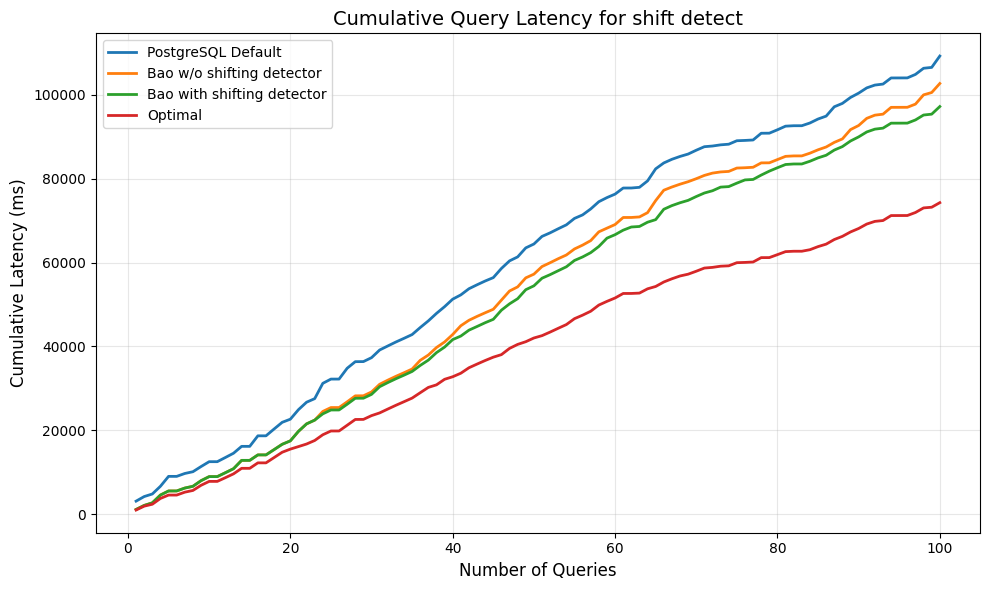

In [6]:
reg = init_bao_model(data)
res = cl(reg,"mmd",data)
res_df = pd.concat(res,ignore_index=True)
plot_res("shift detect", res_df, "results/prototype/latency/performance_10_mmd.png")

### Relationship of MMD score & Regret

## 7. Kolmogorov-Smirnov (KS) test

0 1 KstestResult(statistic=0.1076923076923077, pvalue=0.09804019265056914)
1 0 KstestResult(statistic=0.15, pvalue=0.005698077454928774)
1 1 KstestResult(statistic=0.07307692307692308, pvalue=0.4919667307074757)
2 0 KstestResult(statistic=0.1, pvalue=0.14858851744004908)
2 1 KstestResult(statistic=0.1076923076923077, pvalue=0.09804019265056914)


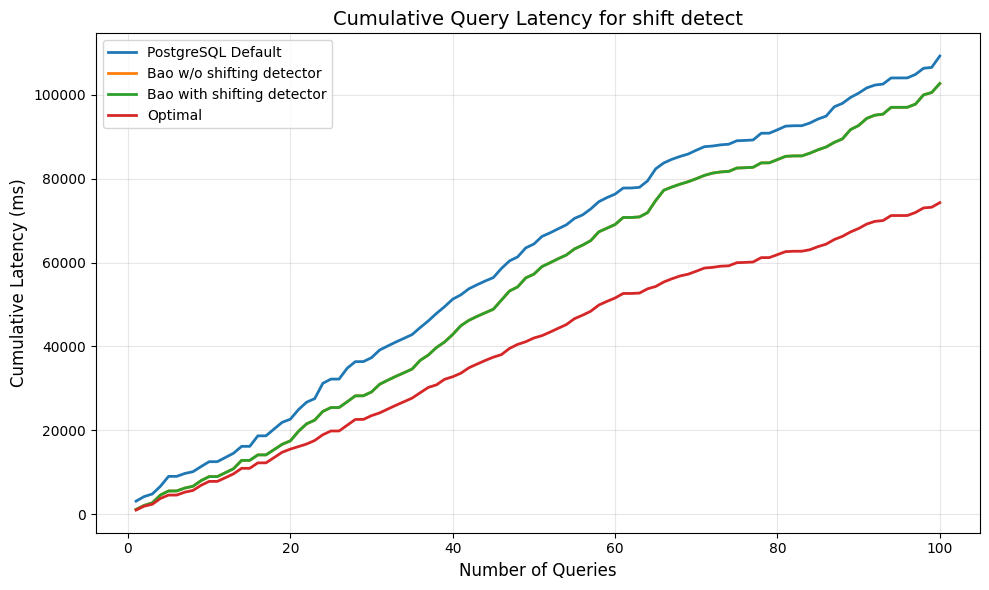

In [9]:
reg = init_bao_model(data)
res = cl(reg,"ks",data)
res_df = pd.concat(res,ignore_index=True)
plot_res("shift detect", res_df, "results/prototype/latency/performance_10_ks.png")

### KL-Divergence Or JSD vs Regrets (Optional)

## 9. Wassertein Distance vs Regrets

0 1 0.3478919240144583
1 0 0.5437464163853571
1 1 0.316610549734189
2 0 0.4107062124288998
2 1 0.37729889521232013


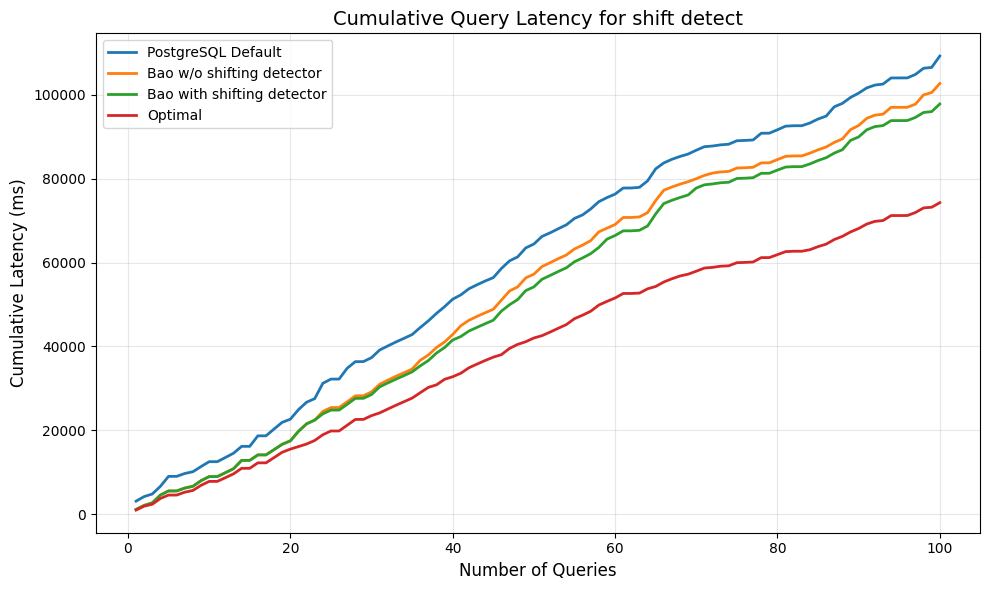

In [8]:
reg = init_bao_model(data)
res = cl(reg,"ws",data)
res_df = pd.concat(res,ignore_index=True)
plot_res("shift detect", res_df, "results/prototype/latency/performance_10_wd.png")

Therefore, I recommend using the following main figures for the final paper:

Normalized Latency (Default/Bao/Optimal) ← Main Figure

Regret vs Phase ← Core Results

MMD Score + Retrain Point ← Method Validation

Top-1 Accuracy ← Auxiliary Results

These four figures should be sufficient to fully support the experimental section of the entire Continual LQO paper.
因此我建议最终论文主图用：
Normalized Latency (Default/Bao/Optimal) ← 主图
Regret vs Phase ← 核心结果
MMD Score + Retrain Point ← 方法验证
Top-1 Accuracy ← 辅助结果
这四张图基本就能完整支撑整个 Continual LQO 论文的实验部分。